gh<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 145.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 142.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 141.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 171.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [3]:
df.columns.tolist()
print(df.dtypes)

ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

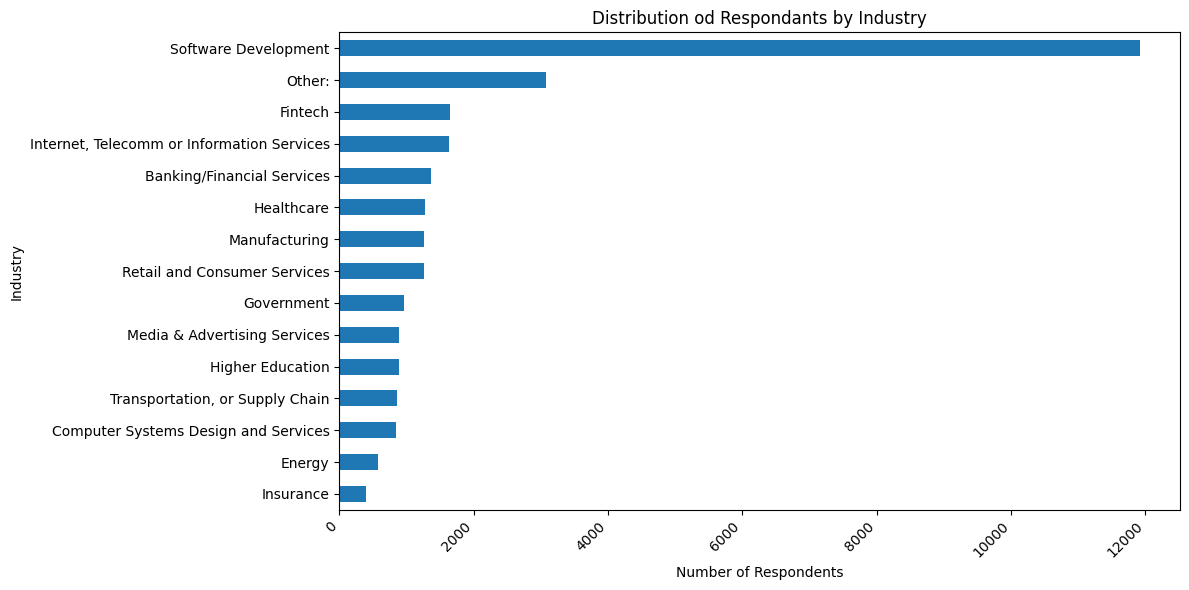

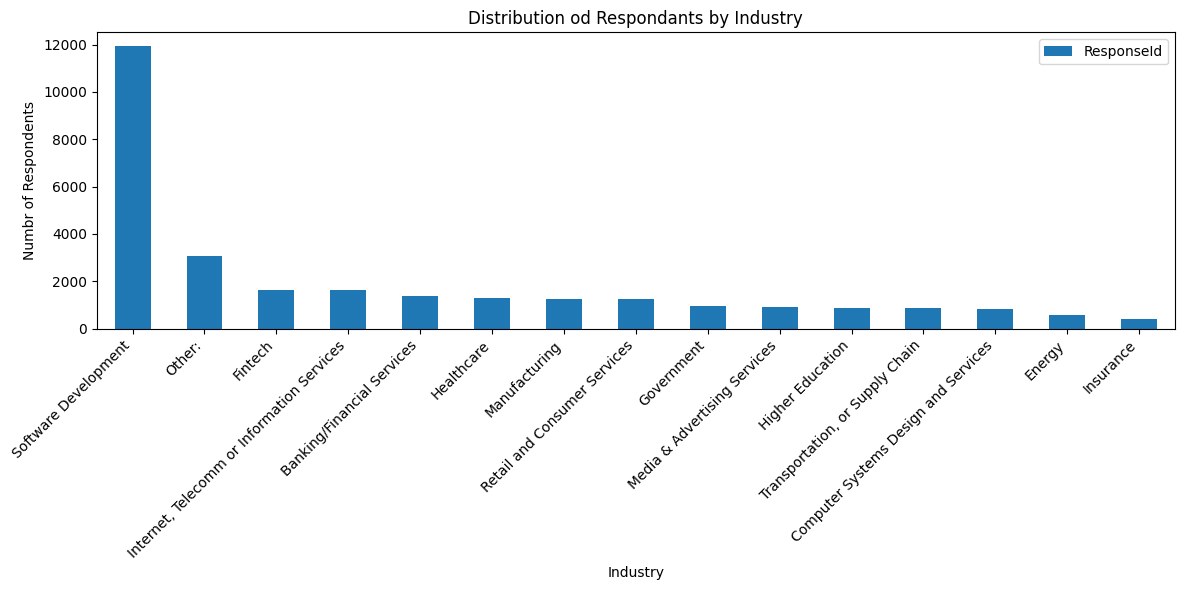

In [4]:
##Write your code here
#columns - Industry (str), ResponseId (int64)

#Count the numnber of respondents - using unique responseid values - 
Industry_counts = (df.groupby('Industry')['ResponseId'].nunique().sort_values(ascending=False))

#plot a bar chart -
plt.figure(figsize=(12,6))
Industry_counts.sort_values().plot(kind='barh')
plt.title('Distribution od Respondants by Industry')
plt.xlabel('Number of Respondents')
plt.ylabel('Industry')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,6))
Industry_counts.plot(kind='bar')
plt.title('Distribution od Respondants by Industry')
plt.xlabel('Industry')
plt.ylabel('Numbr of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

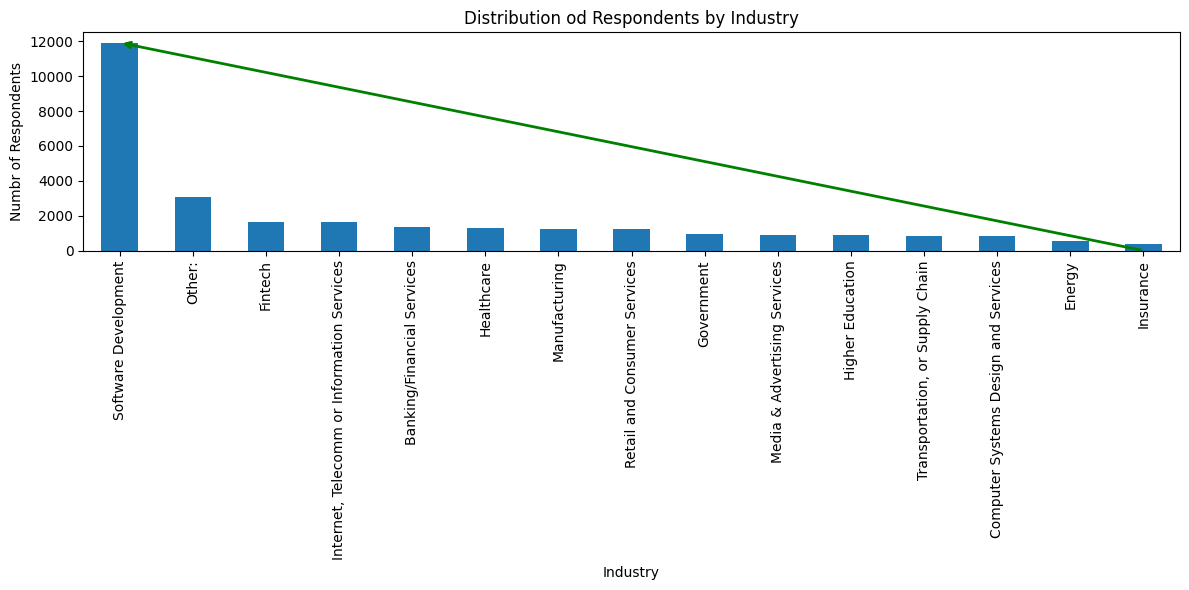

In [5]:
#Count the numnber of respondents - using unique responseid values - 
Industry_counts = (df.groupby('Industry')['ResponseId'].nunique().sort_values(ascending=False))

n = len(Industry_counts)
max_value = Industry_counts.max()

plt.figure(figsize=(12,6))
Industry_counts.plot(kind='bar')


plt.annotate('', xy=(0, Industry_counts.max()), xytext=(len(Industry_counts)-1, 0), arrowprops=dict(arrowstyle='->', color='green', lw=2))


plt.title('Distribution od Respondents by Industry')
plt.xlabel('Industry')
plt.ylabel('Numbr of Respondents')

plt.tight_layout()
plt.show()


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [6]:
##Write your code here
#ConvertedCompYearly  (float64), ResponseId (int64)
comp = df['ConvertedCompYearly'].dropna()
comp.describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [7]:
#standard-deviation
std_val = comp.std()
median_val = comp.median()
mean_val = comp.mean()

print(f'Median: {median_val}')
print(f'Standard Deviation: {std_val}')
print(f'mean: {mean_val}')

#Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean) = 
threshold = mean_val + 3 * std_val

high_earners = df[df['ConvertedCompYearly']>threshold]
low_earners = df[df['ConvertedCompYearly']<threshold]

print(high_earners[['ResponseId', 'ConvertedCompYearly']])
print(low_earners[['ResponseId', 'ConvertedCompYearly']])

Median: 65000.0
Standard Deviation: 186756.97308629754
mean: 86155.28726264134
       ResponseId  ConvertedCompYearly
529           530             650000.0
828           829            1000000.0
1932         1933             945000.0
2171         2172             750000.0
2187         2188            2000000.0
...           ...                  ...
38219       38220            1000000.0
39643       39644            1300000.0
40066       40067             800000.0
40952       40953             750000.0
41027       41028             700000.0

[89 rows x 2 columns]
       ResponseId  ConvertedCompYearly
72             73               7322.0
374           375              30074.0
379           380              91295.0
385           386              53703.0
389           390             110000.0
...           ...                  ...
41180       41181              44640.0
41184       41185             170000.0
41185       41186             116844.0
41186       41187              12000.0
4

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


IQR: 75259.5
upper_bound: 220860.75
lower_bound: -80177.25
       ResponseId  ConvertedCompYearly
428           429             230000.0
456           457             300000.0
461           462             254425.0
529           530             650000.0
545           546             400000.0
...           ...                  ...
40952       40953             750000.0
41000       41001             235000.0
41001       41002             260000.0
41027       41028             700000.0
41187       41188             222834.0

[978 rows x 2 columns]
Empty DataFrame
Columns: [ResponseId, ConvertedCompYearly]
Index: []
Number of outliers: 978
High Outliers: 978
Low outliers: 0

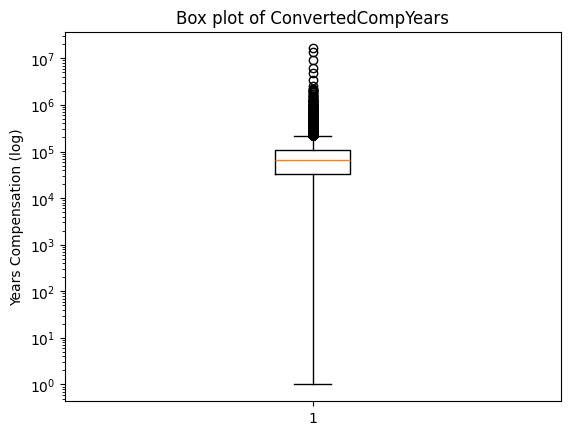

In [8]:
##Write your code here
#Interquartile Range (IQR) for compensation (upper and lower bounds)

Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

print('IQR:', IQR)

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print('upper_bound:', upper_bound)
print('lower_bound:', lower_bound)

high_earners = df[df['ConvertedCompYearly'] > upper_bound]
low_earners = df[df['ConvertedCompYearly'] < lower_bound]

print(high_earners[['ResponseId', 'ConvertedCompYearly']])
print(low_earners[['ResponseId', 'ConvertedCompYearly']])

#2/ outliers for upper and lower
outliers = df[
    (df['ConvertedCompYearly'] < lower_bound) | 
    (df['ConvertedCompYearly'] > upper_bound)]

print('Number of outliers:', len(outliers))

high_outliers = df[df['ConvertedCompYearly'] > upper_bound]
low_outliers = df[df['ConvertedCompYearly'] < lower_bound]

print('High Outliers:', len(high_outliers))
print('Low outliers:', len(low_outliers))

#Final step - create a box plot
plt.figure()
plt.boxplot(comp)
plt.yscale('log')
plt.title('Box plot of ConvertedCompYears')
plt.ylabel('Years Compensation (log)')
color='green'
plt.show()


<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [9]:
##Write your code here
df_new = df[
    (df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound) & (df['ConvertedCompYearly'] > 0)]

print('Origional DataFrame size:', df.shape)
print('New DataFrame size:', df_new.shape)


Origional DataFrame size: (65437, 114)
New DataFrame size: (22457, 114)

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [10]:
df['Age'].tolist()

['Under 18 years old',
 '35-44 years old',
 '45-54 years old',
 '18-24 years old',
 '18-24 years old',
 'Under 18 years old',
 '35-44 years old',
 '18-24 years old',
 '45-54 years old',
 '35-44 years old',
 '35-44 years old',
 '45-54 years old',
 '35-44 years old',
 '35-44 years old',
 '25-34 years old',
 '45-54 years old',
 'Under 18 years old',
 '18-24 years old',
 '25-34 years old',
 '35-44 years old',
 '25-34 years old',
 '35-44 years old',
 '45-54 years old',
 '55-64 years old',
 '35-44 years old',
 '45-54 years old',
 '35-44 years old',
 '25-34 years old',
 '25-34 years old',
 '25-34 years old',
 'Prefer not to say',
 '25-34 years old',
 '25-34 years old',
 '35-44 years old',
 'Under 18 years old',
 '25-34 years old',
 '18-24 years old',
 '25-34 years old',
 '35-44 years old',
 'Under 18 years old',
 '25-34 years old',
 '35-44 years old',
 '35-44 years old',
 '35-44 years old',
 '25-34 years old',
 '25-34 years old',
 '35-44 years old',
 '45-54 years old',
 '65 years or older',
 

                  Age  Age_num
0  Under 18 years old     17.0
1     35-44 years old     21.0
2     45-54 years old     29.5
3     18-24 years old     21.0
4     18-24 years old     21.0
Age_num                1.000000
JobSatPoints_6         0.028009
JobSatPoints_9         0.026552
JobSatPoints_10        0.018678
JobSatPoints_11        0.016994
JobSatPoints_5         0.013035
JobSatPoints_8         0.008238
JobSatPoints_4         0.006689
JobSatPoints_7         0.006609
JobSatPoints_1         0.005165
CompTotal              0.005159
ConvertedCompYearly    0.003739
JobSat                 0.000552
ResponseId            -0.017480
WorkExp               -0.066836
Name: Age_num, dtype: float64

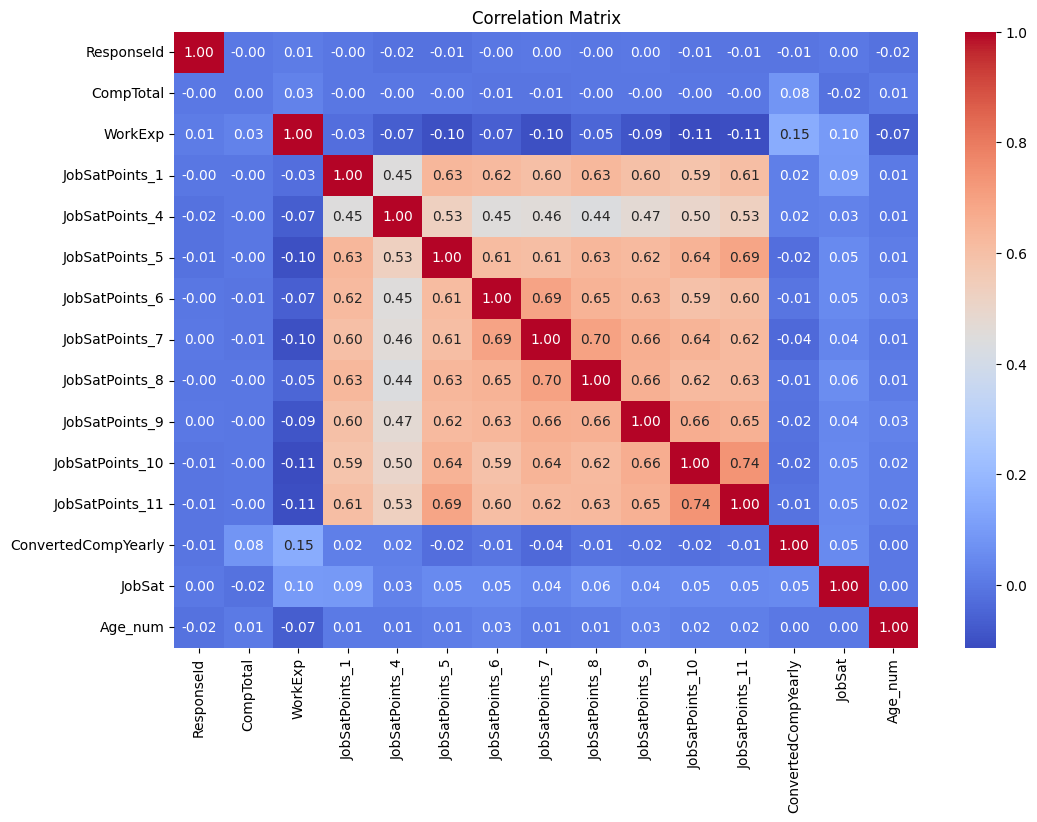

In [20]:
##Write your code here
# 1/ Map the Age column to approximate numeric values. - midpoint = lower+upper/2
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 49.5,
    '35-44 years old': 21 ,    
    '45-54 years old': 29.5,
    '55-64 years old': 59.5,
    '65 years or older': 65}

df['Age_num'] = df['Age'].map(age_map)

print(df[['Age', 'Age_num']].head())

#2/ Compute correlations between Age and other numeric variables.
Num_df = df.select_dtypes(include='number')

age_correlation = Num_df.corr()['Age_num'].sort_values(ascending=False)

print(age_correlation)
#close to 1 → strong positive relationship
#close to -1 → strong negative relationship
#close to 0 → weak or no linear relationship

#3/ Visualize the correlation matrix - Heatmap
corr_matrix = Num_df.corr()

#plot the heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
